# 🔧 Pipeline ML — Preprocessing pour Modèles Immobilier

Ce notebook exécute le pipeline de prétraitement étape par étape avec des visualisations avant/après chaque transformation.

**Pipeline:** `src/cleaning/ml_pipeline.py`  
**Output:** `data/final/` → X_train, X_test, y_train, y_test

---

## 0. Setup

In [6]:
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))

import glob
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings

try:
    import plotly.express as px
    PLOTLY = True
except ImportError:
    PLOTLY = False
    print('plotly non disponible — uniquement matplotlib')

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

print('✅ Setup OK')

✅ Setup OK


## 1. Charger les données brutes

In [7]:
# Charger le fichier combiné le plus récent
files = glob.glob(os.path.join('..', 'data', 'processed', 'immobilier_maroc_*.csv'))
latest = max(files, key=os.path.getctime)
df_raw = pd.read_csv(latest)

print(f'📄 Fichier : {latest}')
print(f'📊 Shape   : {df_raw.shape}')
print(f'📋 Colonnes: {list(df_raw.columns)}')
df_raw.head(5)

📄 Fichier : ..\data\processed\immobilier_maroc_20260321_160003.csv
📊 Shape   : (75, 20)
📋 Colonnes: ['id_annonce', 'source', 'type_bien', 'ville', 'prix', 'surface_m2', 'nb_chambres', 'nb_salles_bain', 'etage', 'parking', 'ascenseur', 'balcon', 'piscine', 'jardin', 'titre', 'description', 'url', 'date_scraping', 'prix_m2', 'score_equipements']


,id_annonce,source,type_bien,ville,prix,surface_m2,nb_chambres,nb_salles_bain,etage,parking,ascenseur,balcon,piscine,jardin,titre,description,url,date_scraping,prix_m2,score_equipements
0,Appartement_%C3%A0_vendre_Mhamid_9_57641654,Avito,Appartement,Marrakech,350000.0,60.0,2.0,1.0,4.0,0,1,0,0,0,Appartement à vendre Mhamid 9,Appartement à vendre au 4ème étage avec ascens...,https://www.avito.ma/fr/m_hamid/appartements/A...,2026-03-21,5833.33,1
1,Appartement_%C3%A0_vendre_57_m%C2%B2_%C3%A0_Ma...,Avito,Appartement,Marrakech,410000.0,NaN,2.0,1.0,2.0,0,0,0,0,0,Appartement à vendre 57 m² à Marrakech,Je mets en vente mon appartement en tres bon é...,https://www.avito.ma/fr/hay_massira/appartemen...,2026-03-21,NaN,0
2,Appartement_%C3%A0_vendre_Saada_55932125,Avito,Appartement,Marrakech,420000.0,52.0,2.0,1.0,2.0,0,1,0,0,0,Appartement à vendre Saada,Appartement à vendre 2 chambres salon salle de...,https://www.avito.ma/fr/es_saada/appartements/...,2026-03-21,8076.92,1
3,Appartement_%C3%A0_vendre_%C3%A0_Saada_pr%C3%A...,Avito,Appartement,Marrakech,475000.0,52.0,2.0,1.0,1.0,0,0,0,0,0,Appartement à vendre à Saada près Marjane,Appartement à vendre à Saada près Marjane \nBe...,https://www.avito.ma/fr/es_saada/appartements/...,2026-03-21,9134.62,0
4,__Appartement_%C3%A0_vendre_pr%C3%A8s_de_Marja...,Avito,Appartement,Marrakech,490000.0,56.0,2.0,1.0,3.0,0,1,0,0,0,😍Appartement à vendre près de Marjane,"⛳ Emplacement : Près de Marjane, route de Casa...",https://www.avito.ma/fr/route_de_casablanca/ap...,2026-03-21,8750.00,1


In [8]:
# Valeurs manquantes initiales
missing = df_raw.isnull().sum()
missing = missing[missing > 0]
print('Valeurs manquantes avant pipeline:')
display(pd.DataFrame({'Manquantes': missing, '%': (missing/len(df_raw)*100).round(1)}))

Valeurs manquantes avant pipeline:


,Manquantes,%
prix,5,6.7
surface_m2,22,29.3
nb_salles_bain,1,1.3
etage,6,8.0
prix_m2,27,36.0


## 2. Lancer le Pipeline Complet

In [9]:
import importlib.util, pathlib

# Import dynamique du pipeline
spec = importlib.util.spec_from_file_location(
    'ml_pipeline',
    str(pathlib.Path('..') / 'src' / 'cleaning' / 'ml_pipeline.py')
)
ml_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(ml_module)

# Exécuter
pipeline = ml_module.MLPipeline(
    data_dir   = os.path.join('..', 'data', 'processed'),
    output_dir = os.path.join('..', 'data', 'final')
)
pipeline.run()
print('\n✅ Pipeline terminé!')

2026-03-21 16:17:26,430 │ INFO │ 
═══════════════════════════════════════════════════════
2026-03-21 16:17:26,432 │ INFO │ 🚀  DÉMARRAGE DU PIPELINE ML
2026-03-21 16:17:26,434 │ INFO │     2026-03-21 16:17:26
2026-03-21 16:17:26,439 │ INFO │ ═══════════════════════════════════════════════════════

2026-03-21 16:17:26,442 │ INFO │ ═══════════════════════════════════════════════════════
2026-03-21 16:17:26,443 │ INFO │ ÉTAPE 1 │ Chargement & Validation du schéma
2026-03-21 16:17:26,445 │ INFO │ ═══════════════════════════════════════════════════════
2026-03-21 16:17:26,447 │ INFO │   Fichier chargé : c:\Users\ayoub\Downloads\scrapping\file rouge\Analyse-du-Marche-Immobilier\data\processed\immobilier_maroc_20260321_160003.csv
2026-03-21 16:17:26,454 │ INFO │   Colonnes : ['id_annonce', 'source', 'type_bien', 'ville', 'prix', 'surface_m2', 'nb_chambres', 'nb_salles_bain', 'etage', 'parking', 'ascenseur', 'balcon', 'piscine', 'jardin', 'titre', 'description', 'url', 'date_scraping', 'prix_m2

2026-03-21 16:17:26,492 │ INFO │   nb_chambres → chambres_num : 70 valides
2026-03-21 16:17:26,500 │ INFO │   etage → etage_num : 64 valides
2026-03-21 16:17:26,504 │ INFO │   nb_salles_bain → salles_bain_num : 69 valides
2026-03-21 16:17:26,506 │ INFO │   Nouvelles colonnes créées : prix_m2, score_equipements, chambres_num, etage_num, salles_bain_num
2026-03-21 16:17:26,508 │ INFO │   Colonnes supprimées : ['id_annonce', 'titre', 'description', 'url', 'date_scraping', 'nb_chambres', 'nb_salles_bain', 'etage']
2026-03-21 16:17:26,513 │ INFO │   ↳ 70 → 70 lignes  (0 supprimées, 0.0%)
2026-03-21 16:17:26,517 │ INFO │   ✅ Features engineerées — colonnes restantes : ['source', 'type_bien', 'ville', 'prix', 'surface_m2', 'parking', 'ascenseur', 'balcon', 'piscine', 'jardin', 'prix_m2', 'score_equipements', 'chambres_num', 'etage_num', 'salles_bain_num']

2026-03-21 16:17:26,518 │ INFO │ ═══════════════════════════════════════════════════════
2026-03-21 16:17:26,520 │ INFO │ ÉTAPE 3 │ Suppre


✅ Pipeline terminé!


## 3. Rapport du Pipeline

In [10]:
with open(os.path.join('..', 'data', 'final', 'pipeline_report.json'), encoding='utf-8') as f:
    report = json.load(f)

print(f"Status  : {report['status']}")
print(f"Timestamp: {report['timestamp']}")
print()

# Résumé des étapes
rows_data = []
for step, info in report['steps'].items():
    if 'rows_before' in info:
        rows_data.append({
            'Étape': step,
            'Avant': info['rows_before'],
            'Après': info['rows_after'],
            'Supprimées': info['dropped']
        })

df_report = pd.DataFrame(rows_data)
display(df_report)

Status  : SUCCESS
Timestamp: 2026-03-21 16:17:26



,Étape,Avant,Après,Supprimées
0,step1_load,75,70,5
1,step2_features,70,70,0
2,step3_outliers,70,70,0
3,step4_imputation,70,70,0
4,step5_encoding,70,70,0
5,step6_scaling,70,70,0


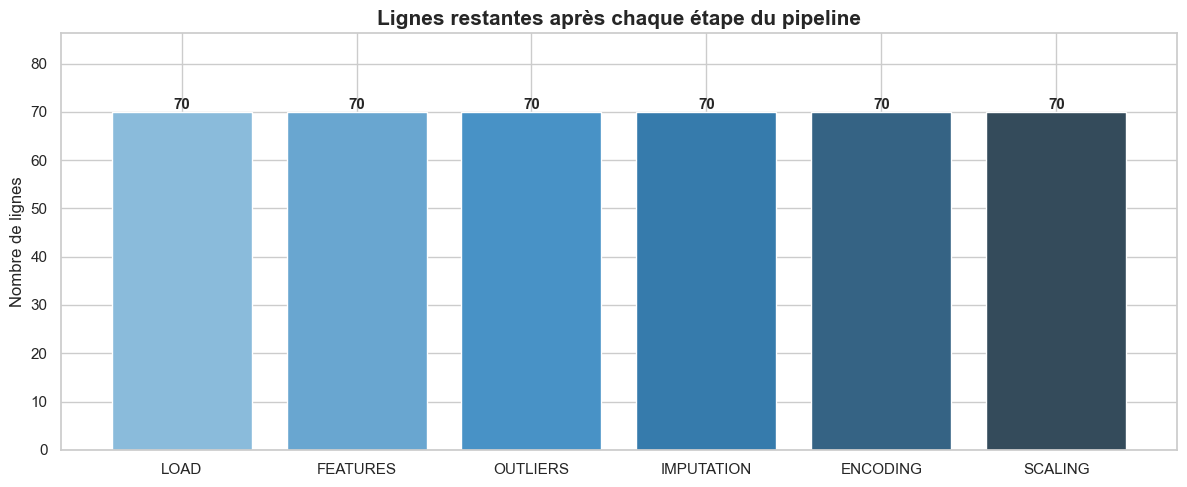

In [11]:
# Visualisation de la réduction de données à chaque étape
fig, ax = plt.subplots(figsize=(12, 5))
steps = df_report['Étape'].str.replace('step\\d+_', '', regex=True).str.upper()
bars = ax.bar(steps, df_report['Après'], color=sns.color_palette('Blues_d', len(steps)))
ax.set_title('Lignes restantes après chaque étape du pipeline', fontsize=15, fontweight='bold')
ax.set_ylabel('Nombre de lignes')
ax.set_ylim(0, df_report['Avant'].max() * 1.15)
for bar, val in zip(bars, df_report['Après']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(val),
            ha='center', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

## 4. Charger les Datasets Finaux

In [12]:
final_dir = os.path.join('..', 'data', 'final')

X_train = pd.read_csv(f'{final_dir}/X_train.csv')
X_test  = pd.read_csv(f'{final_dir}/X_test.csv')
y_train = pd.read_csv(f'{final_dir}/y_train.csv')
y_test  = pd.read_csv(f'{final_dir}/y_test.csv')

print('📦 Datasets chargés:')
print(f'  X_train : {X_train.shape}')
print(f'  X_test  : {X_test.shape}')
print(f'  y_train : {y_train.shape}')
print(f'  y_test  : {y_test.shape}')
print(f'\n  Features: {list(X_train.columns)}')

# Vérification : 0 NaN
nan_train = X_train.isnull().sum().sum()
nan_test  = X_test.isnull().sum().sum()
print(f'\n✅ NaN dans X_train : {nan_train}')
print(f'✅ NaN dans X_test  : {nan_test}')

📦 Datasets chargés:
  X_train : (56, 14)
  X_test  : (14, 14)
  y_train : (56, 1)
  y_test  : (14, 1)

  Features: ['surface_m2', 'parking', 'ascenseur', 'balcon', 'piscine', 'jardin', 'prix_m2', 'score_equipements', 'chambres_num', 'etage_num', 'salles_bain_num', 'type_bien_enc', 'ville_enc', 'source_enc']

✅ NaN dans X_train : 0
✅ NaN dans X_test  : 0


In [13]:
X_train.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])

,count,mean,std,min,25%,50%,75%,max
surface_m2,56.000000,0.013289,1.068824,-1.652887,-0.748964,-0.213632,0.330477,3.893511
parking,56.000000,0.464286,0.503236,0.000000,0.000000,0.000000,1.000000,1.000000
ascenseur,56.000000,0.357143,0.483494,0.000000,0.000000,0.000000,1.000000,1.000000
balcon,56.000000,0.464286,0.503236,0.000000,0.000000,0.000000,1.000000,1.000000
piscine,56.000000,0.357143,0.483494,0.000000,0.000000,0.000000,1.000000,1.000000
jardin,56.000000,0.214286,0.414039,0.000000,0.000000,0.000000,0.000000,1.000000
prix_m2,56.000000,0.094386,1.016853,-1.847887,-0.486909,-0.193461,0.690006,3.053930
score_equipements,56.000000,1.857143,1.554215,0.000000,0.000000,2.000000,3.000000,5.000000
chambres_num,56.000000,-0.059809,1.020812,-1.156306,-1.156306,0.239236,0.239236,3.030318
etage_num,56.000000,0.004383,1.040641,-1.332309,-0.718745,-0.105182,0.508381,1.735507


## 5. Distributions Avant / Après Pipeline

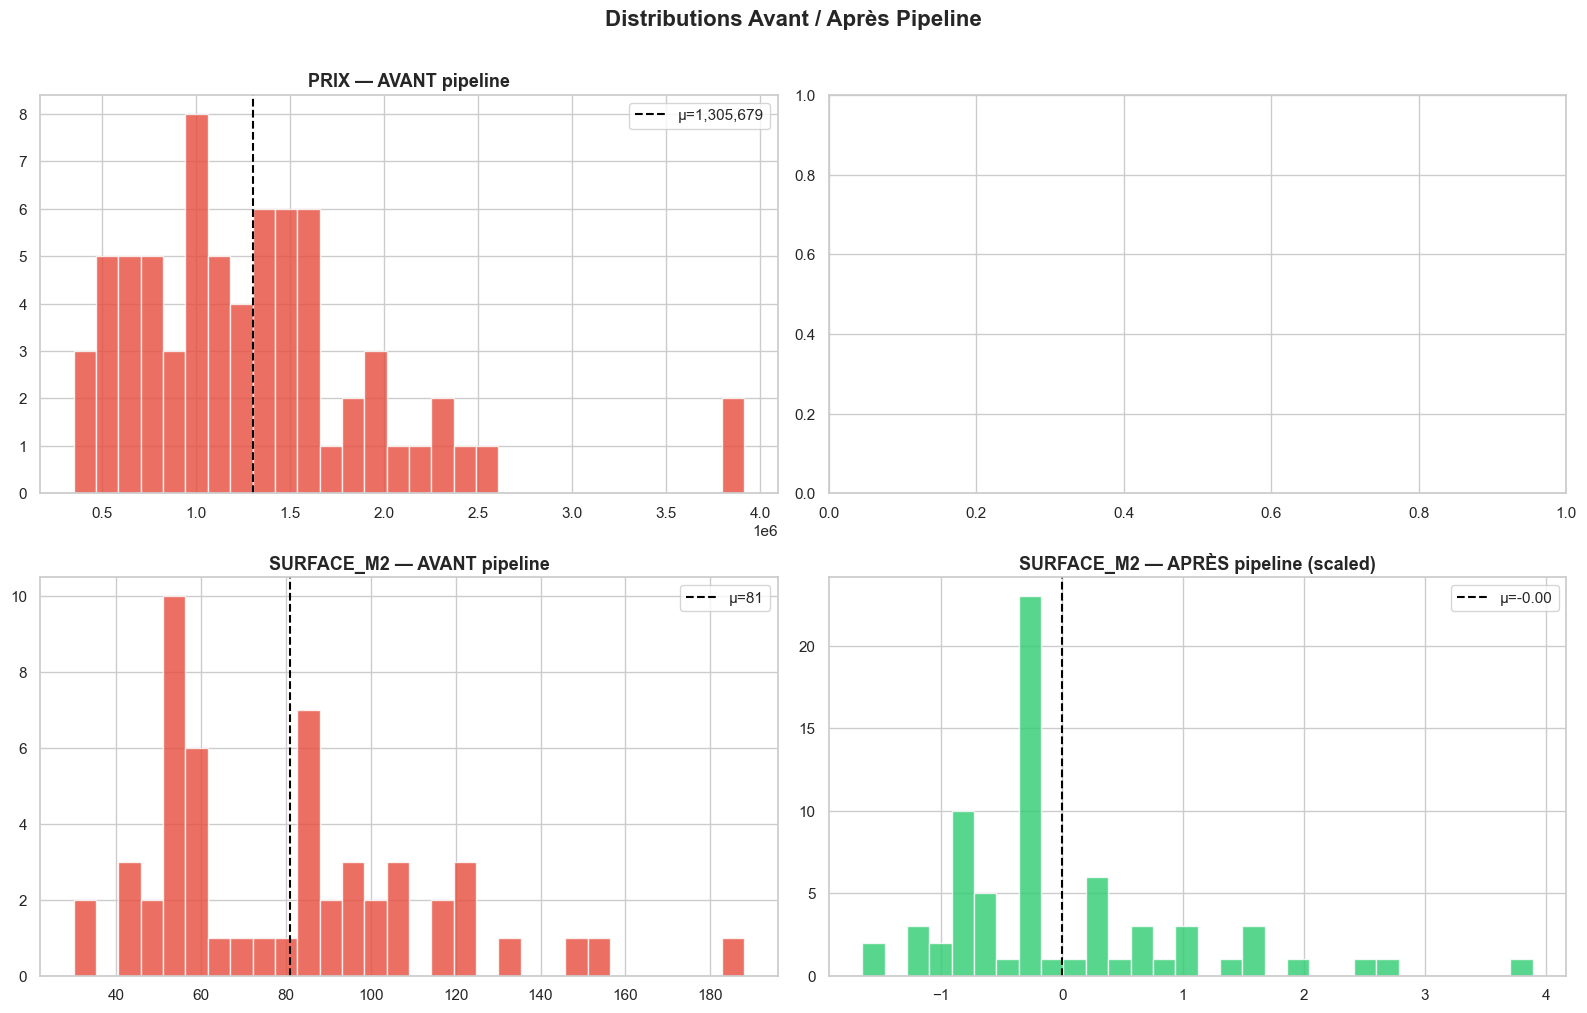

In [14]:
# Refaire le raw pour comparer
df_raw_num = df_raw[['prix', 'surface_m2']].copy()
df_raw_num['prix']       = pd.to_numeric(df_raw_num['prix'], errors='coerce')
df_raw_num['surface_m2'] = pd.to_numeric(df_raw_num['surface_m2'], errors='coerce')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for i, col in enumerate(['prix', 'surface_m2']):
    # Avant
    data_before = df_raw_num[col].dropna()
    axes[i][0].hist(data_before, bins=30, color='#e74c3c', edgecolor='white', alpha=0.8)
    axes[i][0].set_title(f'{col.upper()} — AVANT pipeline', fontsize=13, fontweight='bold')
    axes[i][0].axvline(data_before.mean(), color='black', linestyle='--', label=f'μ={data_before.mean():,.0f}')
    axes[i][0].legend()

    # Après (from X_train/X_test)
    if col in X_train.columns:
        # Scaled — just show distribution shape
        data_after = pd.concat([X_train[col], X_test[col]])
        axes[i][1].hist(data_after, bins=30, color='#2ecc71', edgecolor='white', alpha=0.8)
        axes[i][1].set_title(f'{col.upper()} — APRÈS pipeline (scaled)', fontsize=13, fontweight='bold')
        axes[i][1].axvline(data_after.mean(), color='black', linestyle='--', label=f'μ={data_after.mean():.2f}')
        axes[i][1].legend()

plt.suptitle('Distributions Avant / Après Pipeline', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 6. Distribution de la Target (prix)

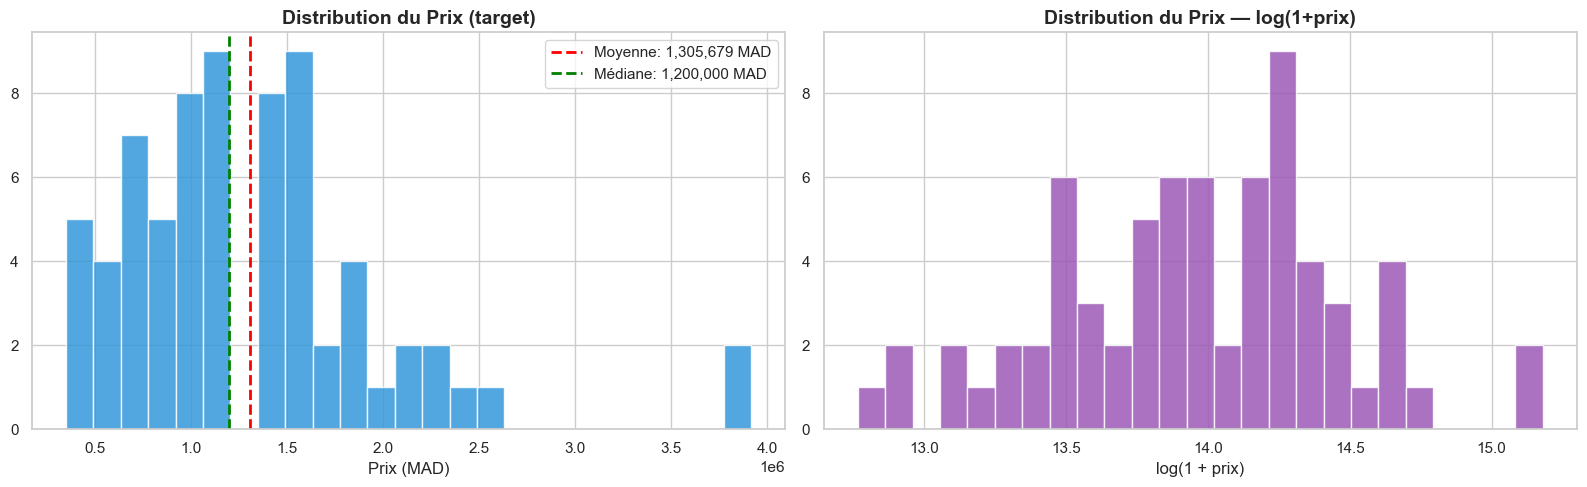

Skewness prix           : 1.619
Skewness log(1+prix)    : -0.101

⚠️ Distribution asymétrique — considérer transformation log(prix) pour les modèles linéaires


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

all_y = pd.concat([y_train, y_test])['prix']

# Distribution normale
axes[0].hist(all_y, bins=25, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].axvline(all_y.mean(),   color='red',   linestyle='--', linewidth=2, label=f'Moyenne: {all_y.mean():,.0f} MAD')
axes[0].axvline(all_y.median(), color='green', linestyle='--', linewidth=2, label=f'Médiane: {all_y.median():,.0f} MAD')
axes[0].set_title('Distribution du Prix (target)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Prix (MAD)')
axes[0].legend()

# Log-scale
axes[1].hist(np.log1p(all_y), bins=25, color='#9b59b6', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribution du Prix — log(1+prix)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('log(1 + prix)')

plt.tight_layout()
plt.show()

skew = all_y.skew()
print(f'Skewness prix           : {skew:.3f}')
print(f'Skewness log(1+prix)    : {np.log1p(all_y).skew():.3f}')
if abs(skew) > 1:
    print('\n⚠️ Distribution asymétrique — considérer transformation log(prix) pour les modèles linéaires')

## 7. Corrélation des Features

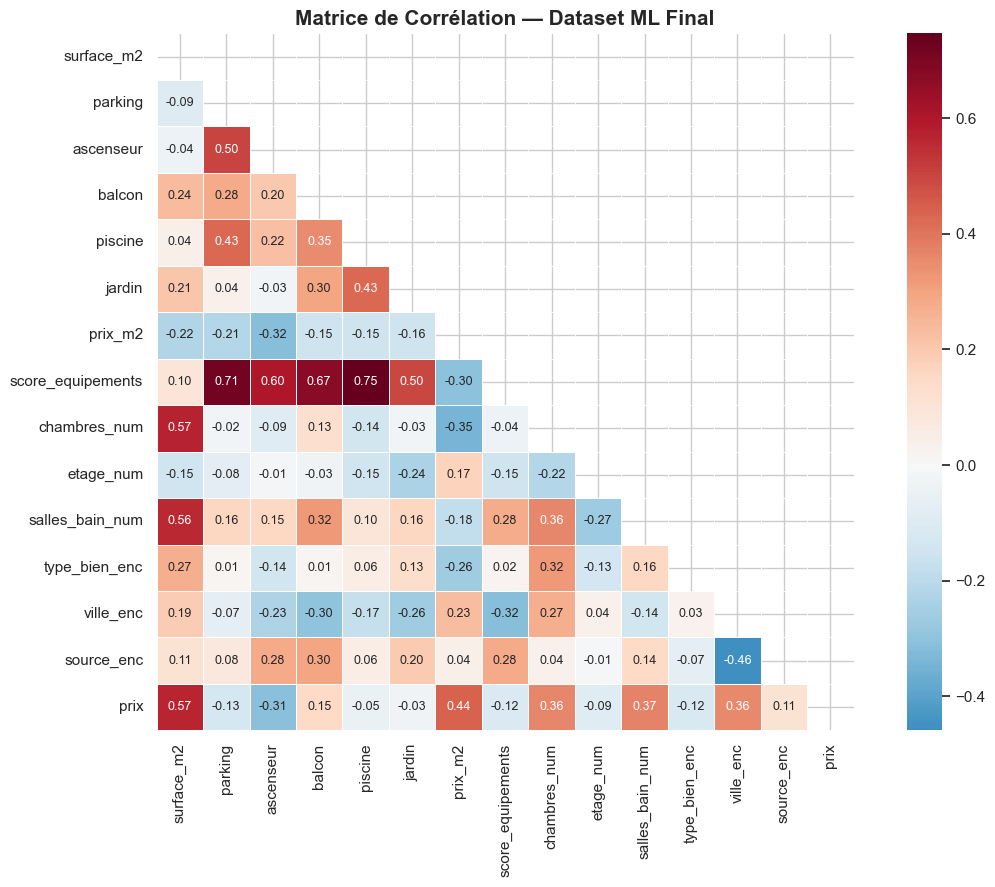


📈 Corrélation avec PRIX (target):


,prix
surface_m2,0.566204
prix_m2,0.436124
salles_bain_num,0.365303
chambres_num,0.364971
ville_enc,0.358550
balcon,0.152518
source_enc,0.110138
jardin,-0.034507
piscine,-0.050556
etage_num,-0.088794


In [16]:
# Matrice de corrélation complète
df_full = X_train.copy()
df_full['prix'] = y_train['prix'].values

corr = df_full.corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 9})
ax.set_title('Matrice de Corrélation — Dataset ML Final', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Corrélation avec le target
print('\n📈 Corrélation avec PRIX (target):')
target_corr = corr['prix'].drop('prix').sort_values(ascending=False)
display(target_corr.to_frame().style.background_gradient(cmap='RdYlGn', axis=0))

## 8. Résumé Final

In [17]:
print('=' * 60)
print('📋 RÉSUMÉ DU DATASET ML')
print('=' * 60)
print(f'  X_train : {X_train.shape[0]:>5} lignes × {X_train.shape[1]} features')
print(f'  X_test  : {X_test.shape[0]:>5} lignes × {X_test.shape[1]} features')
print(f'  y_train : {y_train.shape[0]:>5} lignes (target: prix)')
print(f'  y_test  : {y_test.shape[0]:>5} lignes')
print()
print(f'  NaN dans X_train : {X_train.isnull().sum().sum()}')
print(f'  NaN dans X_test  : {X_test.isnull().sum().sum()}')
print()
print(f'  Prix min (train) : {y_train["prix"].min():>12,.0f} MAD')
print(f'  Prix max (train) : {y_train["prix"].max():>12,.0f} MAD')
print(f'  Prix moyen       : {y_train["prix"].mean():>12,.0f} MAD')
print()
print('  Features :')
for col in X_train.columns:
    print(f'    - {col}')
print('=' * 60)
print('🎯 Dataset prêt pour l\'entraînement des modèles ML!')
print('=' * 60)

📋 RÉSUMÉ DU DATASET ML
  X_train :    56 lignes × 14 features
  X_test  :    14 lignes × 14 features
  y_train :    56 lignes (target: prix)
  y_test  :    14 lignes

  NaN dans X_train : 0
  NaN dans X_test  : 0

  Prix min (train) :      410,000 MAD
  Prix max (train) :    3,915,000 MAD
  Prix moyen       :    1,374,777 MAD

  Features :
    - surface_m2
    - parking
    - ascenseur
    - balcon
    - piscine
    - jardin
    - prix_m2
    - score_equipements
    - chambres_num
    - etage_num
    - salles_bain_num
    - type_bien_enc
    - ville_enc
    - source_enc
🎯 Dataset prêt pour l'entraînement des modèles ML!
